# 04 · Proceso forward sobre imágenes

Análogo del notebook `01` para la **Fase 2** (imágenes). Igual que `01` sobre la mezcla de 8 gaussianas 2D, acá **no hay entrenamiento ni samplers**: solo tocamos la fuente de datos (`diffusion.data_generation`) y el proceso forward (`diffusion.sde`).

El forward es una SDE $dx = f(x,t)\,dt + g(t)\,dW$ cuyo kernel de perturbación es $p_t(x_t \mid x_0) = \mathcal{N}(\mathrm{mean}, \mathrm{std}^2 I)$. Lo visualizamos con `sde.perturb`, que muestrea $x_t = \mathrm{mean} + \mathrm{std}\cdot\varepsilon$. La diferencia con `01`: el estado es una **imagen** $(C,H,W)$ en vez de un punto 2D. Gracias a la generalización N-D (`nd-shapes`), los coeficientes de la SDE broadcastean sobre las dimensiones de imagen sin cambios.

Última columna de cada grilla: el **prior** $p_T$ (VP/sub-VP $\to \mathcal{N}(0,I)$; VE $\to \mathcal{N}(0,\sigma_{\max}^2 I)$).

In [1]:
# --- Setup: bootstrap de sys.path + imports + defaults de ploteo ---
import sys
import pathlib

# El pythonpath del pyproject solo aplica a pytest, no al kernel de Jupyter:
# ubicamos a mano la raíz del paquete (la carpeta que contiene src/diffusion).
_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.data_generation import infinite_batches
from diffusion.sde import make_sde, available_sdes

SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110})

CATS = _root / "data" / "cats-prueba"


def denorm(batch):
    """[-1, 1] -> [0, 1] y (B,3,H,W) -> (B,H,W,3) numpy, listo para imshow."""
    x = (batch * 0.5 + 0.5).clamp(0.0, 1.0)
    return x.permute(0, 2, 3, 1).cpu().numpy()


def show_grid(batch, ncols=8, title=None, cell=1.6):
    """Dibuja un batch (B,3,H,W) en [-1,1] como grilla de imágenes."""
    imgs = denorm(batch)
    n = len(imgs)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(cell * ncols, cell * nrows), squeeze=False)
    for k, ax in enumerate(axes.flat):
        ax.axis("off")
        if k < n:
            ax.imshow(imgs[k])
    if title:
        fig.suptitle(title, y=1.0, fontsize=12)
    fig.tight_layout()
    plt.show()


print("paquete en:", _root)
print("SDEs disponibles:", available_sdes())
print("carpeta de gatos:", CATS, "| existe:", CATS.is_dir())

paquete en: c:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models
SDEs disponibles: ['sub_vp', 've', 'vp']
carpeta de gatos: c:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models\data\cats-prueba | existe: True


## La fuente de datos $p_\text{data}(x_0)$

Las fotos de `cats-prueba`: imágenes RGB reescaladas a $64\times64$, con *center-crop* (preserva el aspecto) y normalizadas a $[-1, 1]$. Para esta visualización desactivamos la *augmentation* (`augment=False`) y el *shuffle*, para tomar un batch **determinista y limpio** de los gatos (sin flips aleatorios).

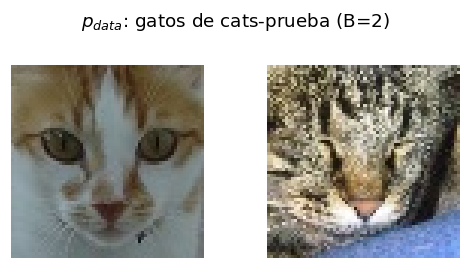

x0: (2, 3, 64, 64) torch.float32 | rango: -1.0 .. 1.0


In [2]:
BATCH = 2  # cats-prueba tiene 2 imágenes; infinite_batches hace fail-fast si pedís más

batches = infinite_batches(
    CATS, batch_size=BATCH, augment=False, shuffle=False, num_workers=0, seed=SEED
)
x0 = next(iter(batches))  # (BATCH, 3, 64, 64) float32 en [-1, 1]

show_grid(x0, ncols=BATCH, title=f"$p_{{data}}$: gatos de cats-prueba (B={BATCH})", cell=2.4)
print("x0:", tuple(x0.shape), x0.dtype, "| rango:", round(float(x0.min()), 3), "..", round(float(x0.max()), 3))

## El proceso forward: imagen → ruido, por SDE

Tomamos un gato y le aplicamos el kernel de perturbación en $t \in \{t_\text{eps}, 0.25, 0.5, 0.75, 1.0\}$, más una muestra del prior $p_T$. Una fila por SDE (VP, VE, sub-VP):

- **VP** y **sub-VP** contraen la media hacia $0$ y llevan la varianza a $1$: el prior es $\mathcal{N}(0, I)$.
- **VE** deja la media (`mean = x0`) y apila ruido con $\sigma(t)$ creciente hasta $\sigma_{\max}=5$: a $t$ grande la imagen queda enterrada en ruido (el `denorm` satura al clampear a $[0,1]$ — es lo esperado).

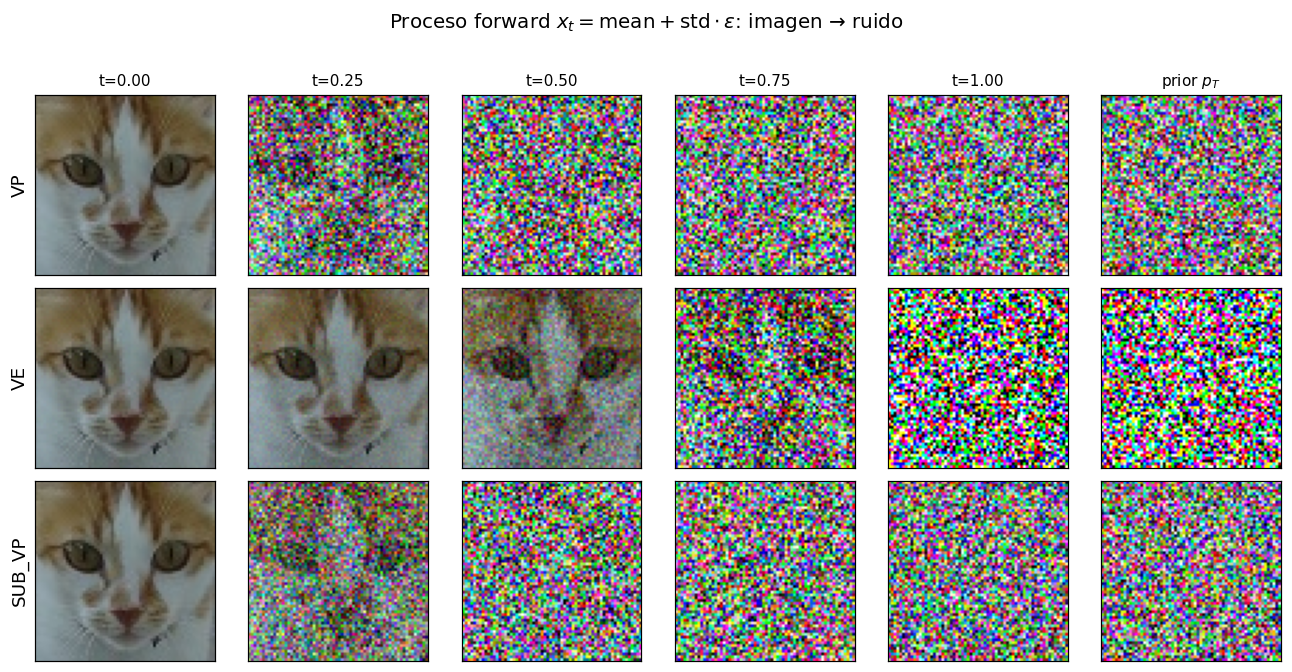

In [3]:
sde_names = ["vp", "ve", "sub_vp"]
t_eps = 1e-4
times = [t_eps, 0.25, 0.5, 0.75, 1.0]
col_titles = [f"t={t:.2f}" for t in times] + ["prior $p_T$"]

img = x0[:1]  # un gato representativo, (1, 3, 64, 64)
n_rows, n_cols = len(sde_names), len(times) + 1
gen = torch.Generator().manual_seed(SEED)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.0 * n_cols, 2.0 * n_rows), squeeze=False)
for i, name in enumerate(sde_names):
    sde = make_sde(name, data_dim=(3, 64, 64))
    for j, t in enumerate(times):
        tt = torch.full((img.shape[0],), float(t))
        xt, _ = sde.perturb(img, tt, generator=gen)
        axes[i, j].imshow(denorm(xt)[0])
    prior = sde.prior_sampling((img.shape[0], *sde.data_shape), generator=gen)
    axes[i, n_cols - 1].imshow(denorm(prior)[0])
    for j in range(n_cols):
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if i == 0:
            axes[i, j].set_title(col_titles[j], fontsize=10)
    axes[i, 0].set_ylabel(name.upper(), fontsize=12)

fig.suptitle("Proceso forward $x_t = \\mathrm{mean} + \\mathrm{std}\\cdot\\varepsilon$: imagen → ruido",
             y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

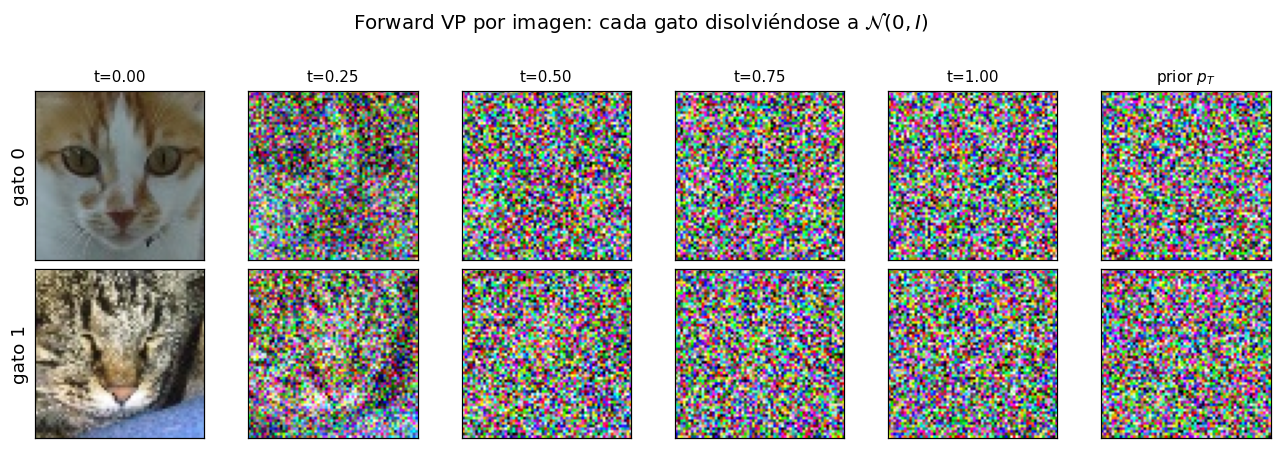

In [4]:
# Bajo VP (la más limpia), la "tira" de difusión forward para cada gato de cats-prueba.
sde = make_sde("vp", data_dim=(3, 64, 64))
gen = torch.Generator().manual_seed(SEED)
n_rows, n_cols = x0.shape[0], len(times) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.0 * n_cols, 2.0 * n_rows), squeeze=False)
for i in range(n_rows):
    img_i = x0[i:i + 1]
    for j, t in enumerate(times):
        tt = torch.full((1,), float(t))
        xt, _ = sde.perturb(img_i, tt, generator=gen)
        axes[i, j].imshow(denorm(xt)[0])
    prior = sde.prior_sampling((1, *sde.data_shape), generator=gen)
    axes[i, n_cols - 1].imshow(denorm(prior)[0])
    for j in range(n_cols):
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if i == 0:
            axes[i, j].set_title(col_titles[j], fontsize=10)
    axes[i, 0].set_ylabel(f"gato {i}", fontsize=12)

fig.suptitle("Forward VP por imagen: cada gato disolviéndose a $\\mathcal{N}(0,I)$", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

## Cómo leer la figura

- En $t \to 0$ (columna `t=0.00`) el estado es prácticamente la foto original: el kernel casi no agregó ruido.
- A medida que $t \to T$, la imagen se disuelve hacia el **prior** $p_T$: VP/sub-VP hacia $\mathcal{N}(0, I)$, VE hacia $\mathcal{N}(0, \sigma_{\max}^2 I)$.
- La escala del prior fija la dificultad del **proceso reverso**: VE arranca de un ruido mucho más ancho, así que su reverso tiene más terreno que recorrer.
- Es exactamente la misma dinámica que en `01` sobre puntos 2D; lo único que cambió es la forma del dato $(C,H,W)$ — el marco de SDEs es idéntico gracias a la generalización N-D.

Con el forward visualizado sobre imágenes, el siguiente paso de la Fase 2 es entrenar la `ScoreUNet` y correr el reverso para **generar** gatos nuevos — el análogo de imágenes de `02`.